In [12]:
# see what tqa clusters do not have label
import pandas as pd
tqa_parquet = pd.read_parquet('/vol/bitbucket/lst20/lex-eval_dataset/TQA/shuffled.parquet')
print(len(tqa_parquet), tqa_parquet.columns)

1000 Index(['Unnamed: 0', 'possible_answers', 's_wiki_title', 'question',
       'cluster_id', 'original_index'],
      dtype='object')


In [11]:
import pickle
import os

# Path to the directory containing the .pkl files
pkl_dir = "/homes/lst20/fyp/fyp_resources/LexEval-main/analysis/tqa_emb"

# Explicitly sort the filenames from tqa_embedding_0.pkl to tqa_embedding_9.pkl
pkl_files = [f"tqa_embedding_{i}.pkl" for i in range(10)]

# Load and combine all embeddings
all_embeddings = []

for file_name in pkl_files:
    file_path = os.path.join(pkl_dir, file_name)
    print(f"Loading: {file_path}")
    with open(file_path, 'rb') as f:
        embeddings = pickle.load(f)
        all_embeddings.extend(embeddings)

print(f"Total number of embeddings: {len(all_embeddings)}")


Loading: /homes/lst20/fyp/fyp_resources/LexEval-main/analysis/tqa_emb/tqa_embedding_0.pkl
Loading: /homes/lst20/fyp/fyp_resources/LexEval-main/analysis/tqa_emb/tqa_embedding_1.pkl
Loading: /homes/lst20/fyp/fyp_resources/LexEval-main/analysis/tqa_emb/tqa_embedding_2.pkl
Loading: /homes/lst20/fyp/fyp_resources/LexEval-main/analysis/tqa_emb/tqa_embedding_3.pkl
Loading: /homes/lst20/fyp/fyp_resources/LexEval-main/analysis/tqa_emb/tqa_embedding_4.pkl
Loading: /homes/lst20/fyp/fyp_resources/LexEval-main/analysis/tqa_emb/tqa_embedding_5.pkl
Loading: /homes/lst20/fyp/fyp_resources/LexEval-main/analysis/tqa_emb/tqa_embedding_6.pkl
Loading: /homes/lst20/fyp/fyp_resources/LexEval-main/analysis/tqa_emb/tqa_embedding_7.pkl
Loading: /homes/lst20/fyp/fyp_resources/LexEval-main/analysis/tqa_emb/tqa_embedding_8.pkl
Loading: /homes/lst20/fyp/fyp_resources/LexEval-main/analysis/tqa_emb/tqa_embedding_9.pkl
Total number of embeddings: 1000


In [16]:
import sys
import os

# Get the parent directory of the current working directory
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)

# Now import
from adapters.OAI_Embeddings import RobertaEmbedder

# Instantiate the embedder
embedder = RobertaEmbedder()


In [31]:
import pandas as pd
from adapters.OAI_Embeddings import RobertaEmbedder
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_distances
import numpy as np
import torch
import os

# Load questions
tqa_parquet = pd.read_parquet('/vol/bitbucket/lst20/lex-eval_dataset/TQA/shuffled.parquet')
questions = tqa_parquet['question'].tolist()

# Embed all questions
embedder = RobertaEmbedder()
batch_size = 64
all_embeddings = []

print("Encoding questions...")
for i in range(0, len(questions), batch_size):
    batch = questions[i:i+batch_size]
    batch_embeddings = embedder.encode(batch)
    if isinstance(batch_embeddings, torch.Tensor):
        batch_embeddings = batch_embeddings.cpu().numpy()
    all_embeddings.extend(batch_embeddings)

# Convert to NumPy array
X = np.array(all_embeddings)

# Save embeddings to file (as PyTorch tensor)
save_dir = "tqa_emb"
os.makedirs(save_dir, exist_ok=True)
torch.save(torch.tensor(X), os.path.join(save_dir, "tqa_all_embeddings.pt"))
print(f"✅ Saved {X.shape[0]} embeddings to {save_dir}/tqa_all_embeddings.pt")

# KMeans clustering
k = 25
kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
cluster_ids = kmeans.fit_predict(X)

# Cosine distance to centroids
distances = cosine_distances(X, kmeans.cluster_centers_)

# Print top 10 closest questions per cluster
for cluster_id in range(k):
    cluster_indices = np.where(cluster_ids == cluster_id)[0]
    sorted_by_distance = cluster_indices[np.argsort(distances[cluster_indices, cluster_id])]

    print(f"\n=== Cluster {cluster_id} ===")
    for i in range(min(10, len(sorted_by_distance))):
        q_idx = sorted_by_distance[i]
        print(f"{i+1}. {questions[q_idx]}")


Encoding questions...


/vol/bitbucket/lst20/lex-eval/lib/python3.12/site-packages/torch/__init__.py:1113: FutureWarning: `torch.distributed.reduce_op` is deprecated, please use `torch.distributed.ReduceOp` instead
  return isinstance(obj, torch.Tensor)


✅ Saved 1000 embeddings to tqa_emb/tqa_all_embeddings.pt

=== Cluster 0 ===
1. What was Victoria Beckham's nickname when she was in the Spice Girls?
2. Louise Redknapp was a member of which all girl pop group?
3. What was the title of Britney Spears' second album (and the single that was released from it)?
4. In Sex in the City, what was Carrie's last name?
5. What is Alistair Cooke's real first name?
6. In which European country did Spice Girl Victoria Adams marry?
7. The 'Pet Shop Boys' are Neil Tennant and who?
8. Little Monsters are Twitter followers of which female singer-songwriter? ;
9. Which is the lowest female singing voice
10. Which fashion designer was chiefly responsible for the popularization of  the Little Black Dress?

=== Cluster 1 ===
1. What was the first name of Mr. Ferrari, the founder of the car manufacturing company?
2. In which city is the HQ of Mercedes cars?
3. Which motor manufacturer produces the Duster model?
4. Which now defunct car company manufactured th

Running t-SNE (may take a few minutes)...


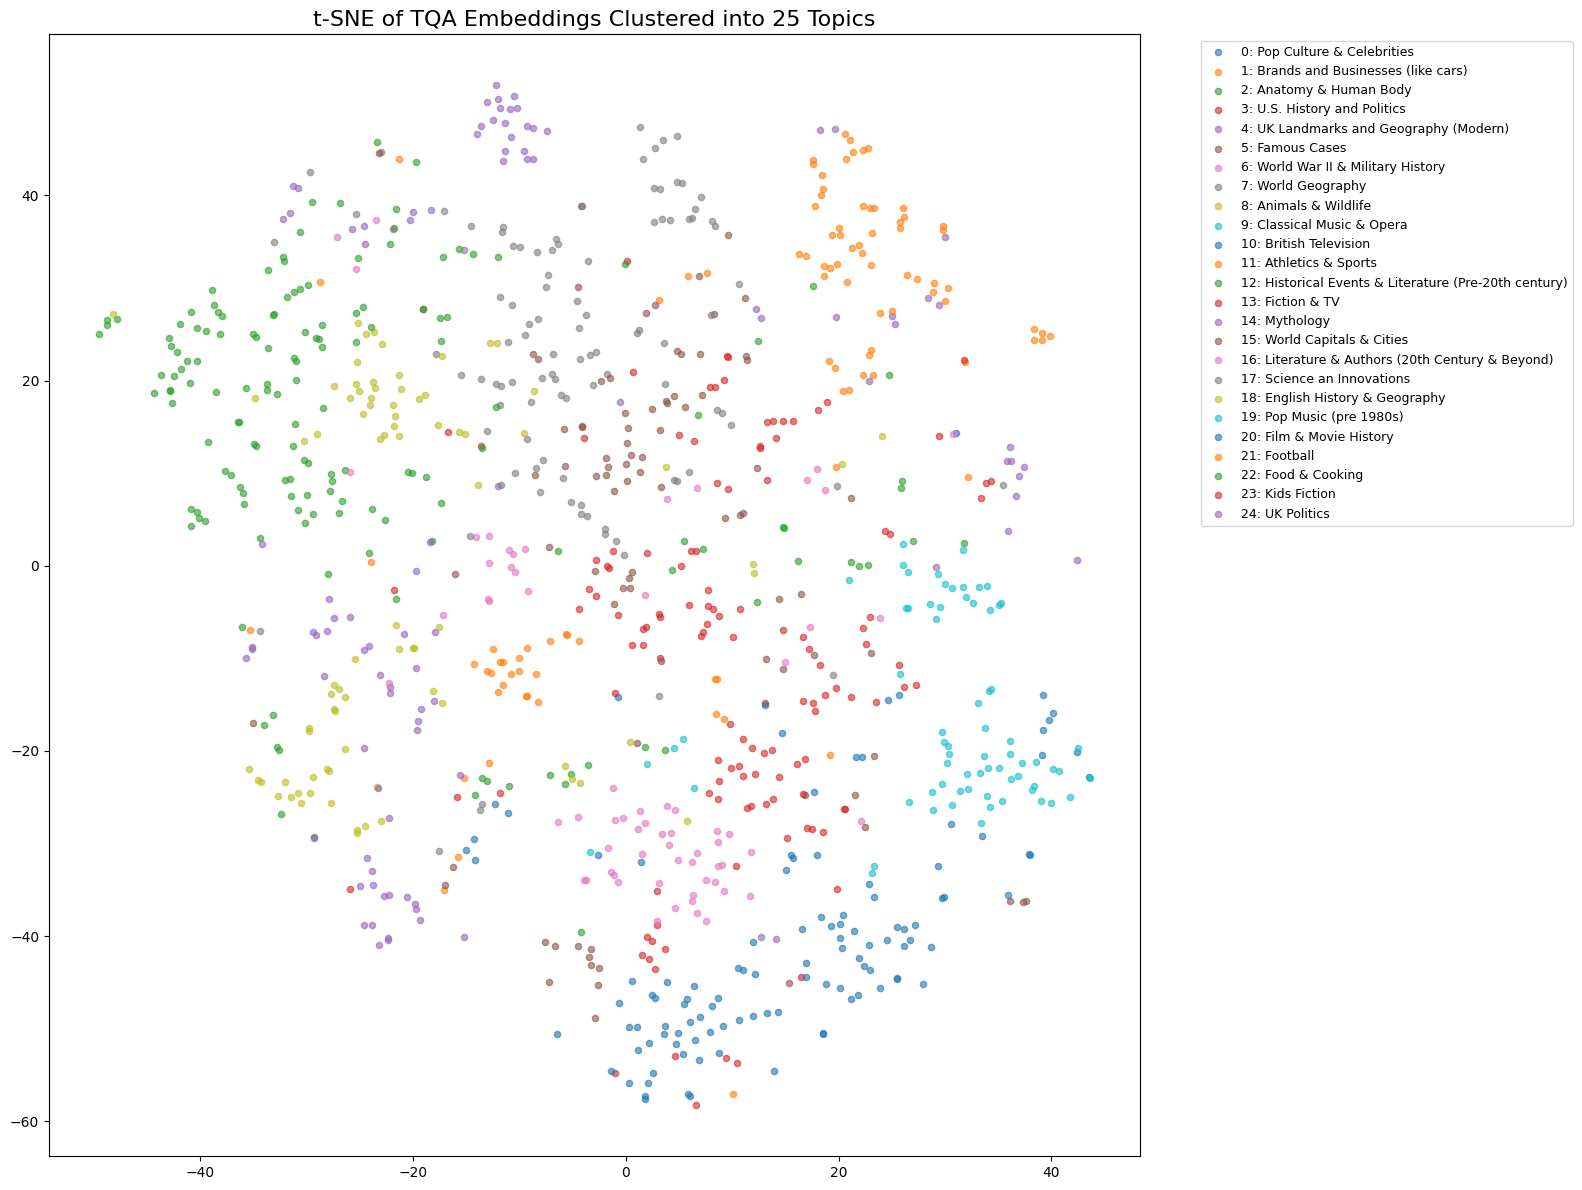

In [32]:
import torch
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# Load embeddings and cluster IDs
embeddings = torch.load("tqa_emb/tqa_all_embeddings.pt").numpy()

# Run KMeans again if needed (or reuse cluster_ids if you saved them)
from sklearn.cluster import KMeans
k = 25
kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
# Your cluster label descriptions
cluster_labels = [
    "Pop Culture & Celebrities",
    "Brands and Businesses (like cars)",
    "Anatomy & Human Body",
    "U.S. History and Politics",
    "UK Landmarks and Geography (Modern)",
    "Famous Cases",
    "World War II & Military History",
    "World Geography",
    "Animals & Wildlife",
    "Classical Music & Opera",
    "British Television",
    "Athletics & Sports",
    "Historical Events & Literature (Pre-20th century)",
    "Fiction & TV",
    "Mythology",
    "World Capitals & Cities",
    "Literature & Authors (20th Century & Beyond)",
    "Science an Innovations",
    "English History & Geography",
    "Pop Music (pre 1980s)",
    "Film & Movie History",
    "Football",
    "Food & Cooking",
    "Kids Fiction",
    "UK Politics"
]


# Run t-SNE
print("Running t-SNE (may take a few minutes)...")
tsne = TSNE(
    perplexity=20,        # lower = focus on local structure
    learning_rate=80,   # lower = more compact clusters
    random_state=42,
    init='pca'
)
X_tsne = tsne.fit_transform(embeddings)

# Plot
plt.figure(figsize=(16, 12))
palette = sns.color_palette("tab20") + sns.color_palette("tab20b")
palette = palette[:k]
for cluster_id in range(k):
    idxs = np.where(cluster_ids == cluster_id)[0]
    plt.scatter(X_tsne[idxs, 0], X_tsne[idxs, 1], 
                label=f"{cluster_id}: {cluster_labels[cluster_id]}", 
                alpha=0.6, s=20)

plt.title("t-SNE of TQA Embeddings Clustered into 25 Topics", fontsize=16)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()


Running t-SNE (may take a few minutes)...


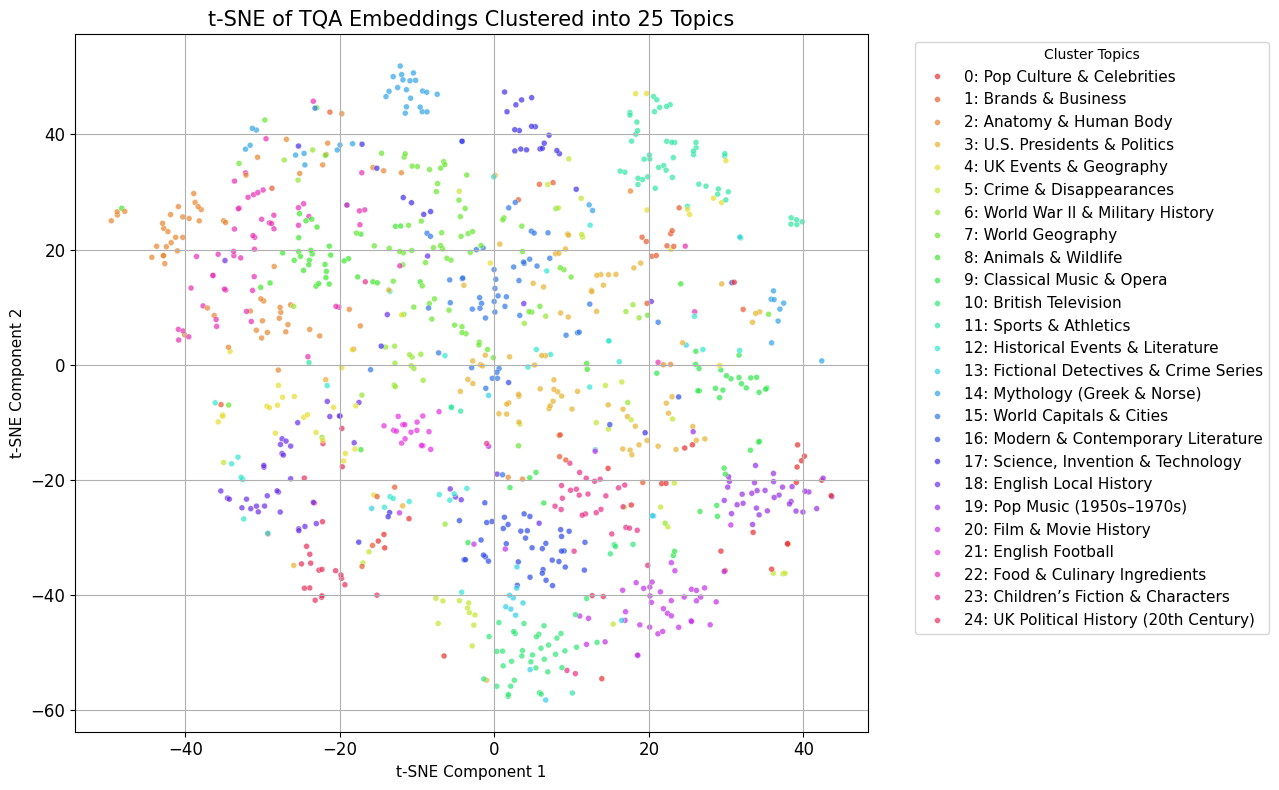

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.manifold import TSNE
from matplotlib.colors import hsv_to_rgb

# Run t-SNE
print("Running t-SNE (may take a few minutes)...")
tsne = TSNE(
    perplexity=20,
    learning_rate=80,
    random_state=42,
    init='pca'
)
X_tsne = tsne.fit_transform(embeddings)

# Ordered cluster labels
cluster_labels = [
    "Pop Culture & Celebrities",         # 0
    "Brands & Business",                 # 1
    "Anatomy & Human Body",              # 2
    "U.S. Presidents & Politics",        # 3
    "UK Events & Geography",             # 4
    "Crime & Disappearances",            # 5
    "World War II & Military History",   # 6
    "World Geography",                   # 7
    "Animals & Wildlife",                # 8
    "Classical Music & Opera",           # 9
    "British Television",                #10
    "Sports & Athletics",                #11
    "Historical Events & Literature",    #12
    "Fictional Detectives & Crime Series",#13
    "Mythology (Greek & Norse)",         #14
    "World Capitals & Cities",           #15
    "Modern & Contemporary Literature",  #16
    "Science, Invention & Technology",   #17
    "English Local History",             #18
    "Pop Music (1950s–1970s)",           #19
    "Film & Movie History",              #20
    "English Football",                  #21
    "Food & Culinary Ingredients",       #22
    "Children’s Fiction & Characters",   #23
    "UK Political History (20th Century)"#24
]

# Map cluster IDs to topic names
cluster_names = [f"{i}: {cluster_labels[i]}" for i in cluster_ids]

tsne_df = pd.DataFrame({
    "x": X_tsne[:, 0],
    "y": X_tsne[:, 1],
    "cluster_id": cluster_ids,
    "cluster_name": pd.Categorical(
        [f"{i}: {cluster_labels[i]}" for i in cluster_ids],
        categories=[f"{i}: {label}" for i, label in enumerate(cluster_labels)],
        ordered=True
    )
})

# Desaturated HSV palette
def desaturated_hsv_palette(n, saturation=0.8, value=0.9):
    return [hsv_to_rgb((i / n, saturation, value)) for i in range(n)]

palette = desaturated_hsv_palette(k)

# # Use HSV color palette for high distinction
# palette = sns.color_palette("hsv", len(cluster_labels))

# Plot
plt.figure(figsize=(13, 8))
sns.scatterplot(
    data=tsne_df,
    x="x", y="y",
    hue="cluster_name",
    palette=palette,
    alpha=0.7,
    s=18
)

plt.title("t-SNE of TQA Embeddings Clustered into 25 Topics", fontsize=15)
plt.xlabel("t-SNE Component 1", fontsize=11)
plt.ylabel("t-SNE Component 2", fontsize=11)

# Ordered legend outside the plot
plt.legend(
    title="Cluster Topics",
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize=11,
    borderaxespad=0.5
)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()


Running t-SNE (may take a few minutes)...


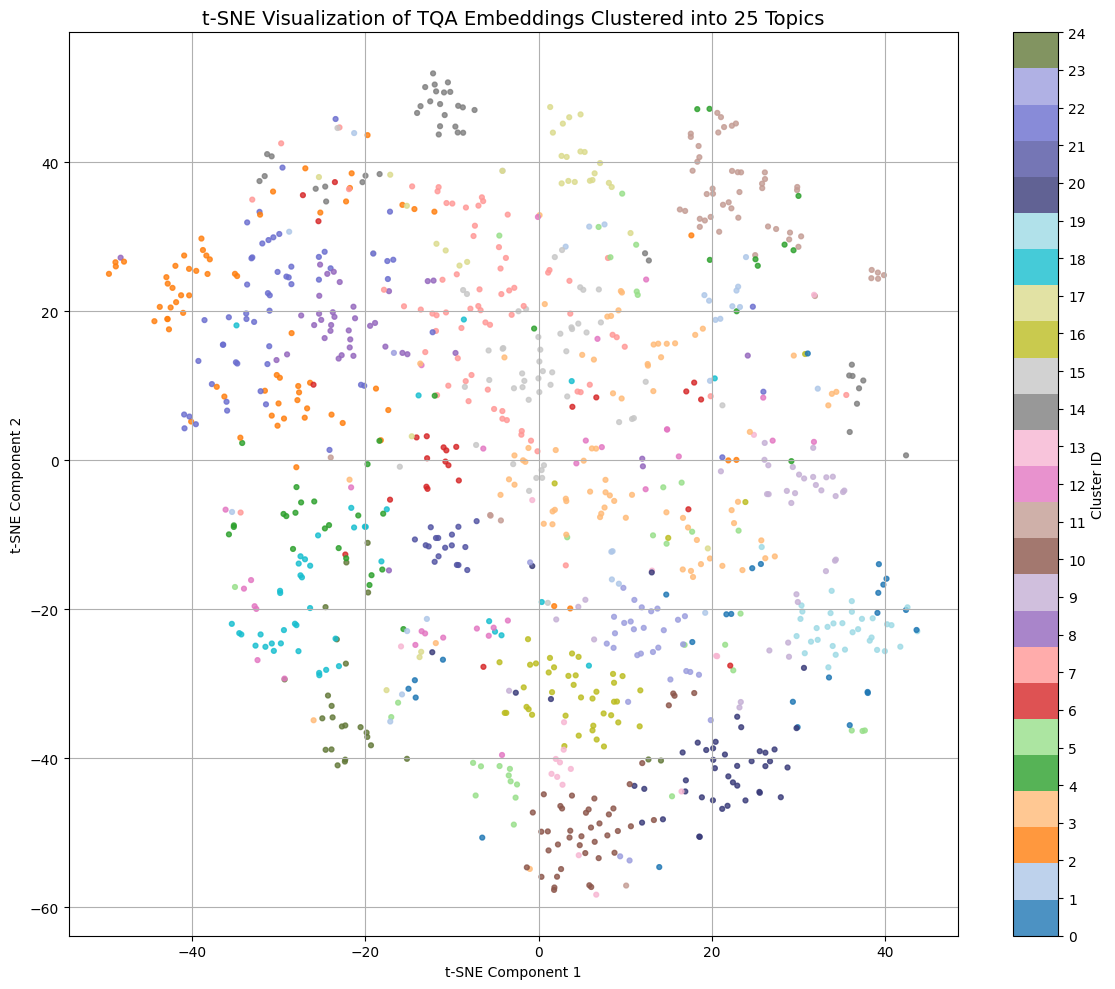

In [29]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np


print("Running t-SNE (may take a few minutes)...")
tsne = TSNE(
    perplexity=20,        # lower = focus on local structure
    learning_rate=80,   # lower = more compact clusters
    random_state=42,
    init='pca'
)
emb_2d = tsne.fit_transform(embeddings)
# Assume emb_2d is your t-SNE output (shape: [n_samples, 2])
# Assume cluster_ids contains values in 0–24

# Extract and combine tab20 + tab20b colors
colors1 = plt.get_cmap('tab20').colors
colors2 = plt.get_cmap('tab20b').colors
combined_colors = colors1 + colors2  # 20 + 20 = 40 colors
custom_cmap = ListedColormap(combined_colors[:25])  # Use only first 25

# Plot
plt.figure(figsize=(12, 10))
scatter = plt.scatter(
    emb_2d[:, 0], emb_2d[:, 1],
    c=cluster_ids, cmap=custom_cmap, s=12, alpha=0.8
)

# Optional: color bar to show cluster IDs
cbar = plt.colorbar(scatter, ticks=range(25), label='Cluster ID')
cbar.set_ticks(range(25))
cbar.set_label("Cluster ID")

# Decorate plot
plt.title("t-SNE Visualization of TQA Embeddings Clustered into 25 Topics", fontsize=14)
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.grid(True)
plt.tight_layout()
plt.show()
